In [1]:
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.ticker as ticker
import textwrap

In [2]:
df = pd.read_csv('../datasets/data.csv')

In [3]:
df.head()

,ID,Main Author,Year,Location,Input Body Part,Gesture,Interaction_PANEL_Number of Selected Gestures,Interaction_PANEL_Resolution,Interaction_PANEL_Hands-Free,Interaction_PANEL_Eyes-Free,...,Device_PANEL_Device Model,Device_PANEL_Real-Time Processing,Device_PANEL_On-Device Processing,Motivations_PANEL_Motivations,Applications_PANEL_Intended Applications,Keywords,Abstract,Study Link,Title,Authors
0,1,Weisenberger et al.,1987,Actuation,NaN,Vibration (Actuation),1,Fine,Yes,Yes,...,NaN,NaN,NaN,"System Extension, Societal Impact, Novel Inter...","Accessibility, Health",NaN,A binaural earmold sound-to-tactile aid was co...,https://www.researchgate.net/publication/19575...,Development and preliminary evaluation of an e...,"Janet M. Weisenberger, Arnold F. Heidbreder, J..."
1,2,Brewster et al.,2003,Head Gestures and Pointing,Head,"Pitch, Roll",1,Coarse,Yes,Yes,...,NaN,Yes,No,"Novel Interaction Technique, System Extension,...",Device Control/Input,"Gestural Interaction, Wearable Computing",Mobile and wearable computers present input/ou...,https://dl.acm.org/doi/abs/10.1145/642611.642694,Multimodal ‘Eyes-Free’ Interaction Techniques ...,"Stephen Brewster, Joanna Lumsden, Marek Bell, ..."
2,3,Metzger et al.,2004,"Hand Gestures and Location, Head Gestures and ...","Hand, Head","Hold (Mid-Air), Roll, Slide (Mid-Air)",7,"Coarse, Semantic",No,Yes,...,NaN,Yes,No,Performance Optimization,"Accessibility, Device Control/Input, Music Pla...","Accelerometers, Control Systems, Digital Audio...","We present FreeDigiter, an interface for mobil...",https://ieeexplore.ieee.org/document/1364684,FreeDigiter: A Contact–free Device for Gesture...,"Christian Metzger, Matt Anderson, Thad Starner"
3,4,Buil & Hollemans,2005,Ear and Earable,Hand,Press (Earable),3,Semantic,No,Yes,...,NaN,Yes,Yes,User-Centered Design,Music Player,"Bluetooth, Communication System Control, Ear, ...",The touch headphones are a solution for provid...,https://ieeexplore.ieee.org/abstract/document/...,Acceptable Operating Force for Buttons on In-E...,"Vincent Buil, Gerard Hollemans"
4,5,Buil et al.,2005,Ear and Earable,"Hand, Wearable State","Attach Earbud, Hold (Earable), Remove Earbud, ...",5,Semantic,No,Yes,...,NaN,Yes,No,"System Extension, User-Centered Design","Device Control/Input, Music Player","Capacitive Touch Control, Headphones, MP3, Mus...",The Touch Headphones are meant for portable mu...,https://dl.acm.org/doi/abs/10.1145/1085777.108...,Headphones with Touch Control,"Vincent Buil, Gerard Hollemans, Sander van de..."


#### Snapshot of EarXplore (Plots by Guiding Questions)

C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:159: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax1, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:168: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=labels, y=values, ax=ax2, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:181: UserWarning: 
The palette list has fewer values (10) than needed (26) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=labels, y=values, ax=ax3_top, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:182: UserWarning: 
The palette list has fewer va

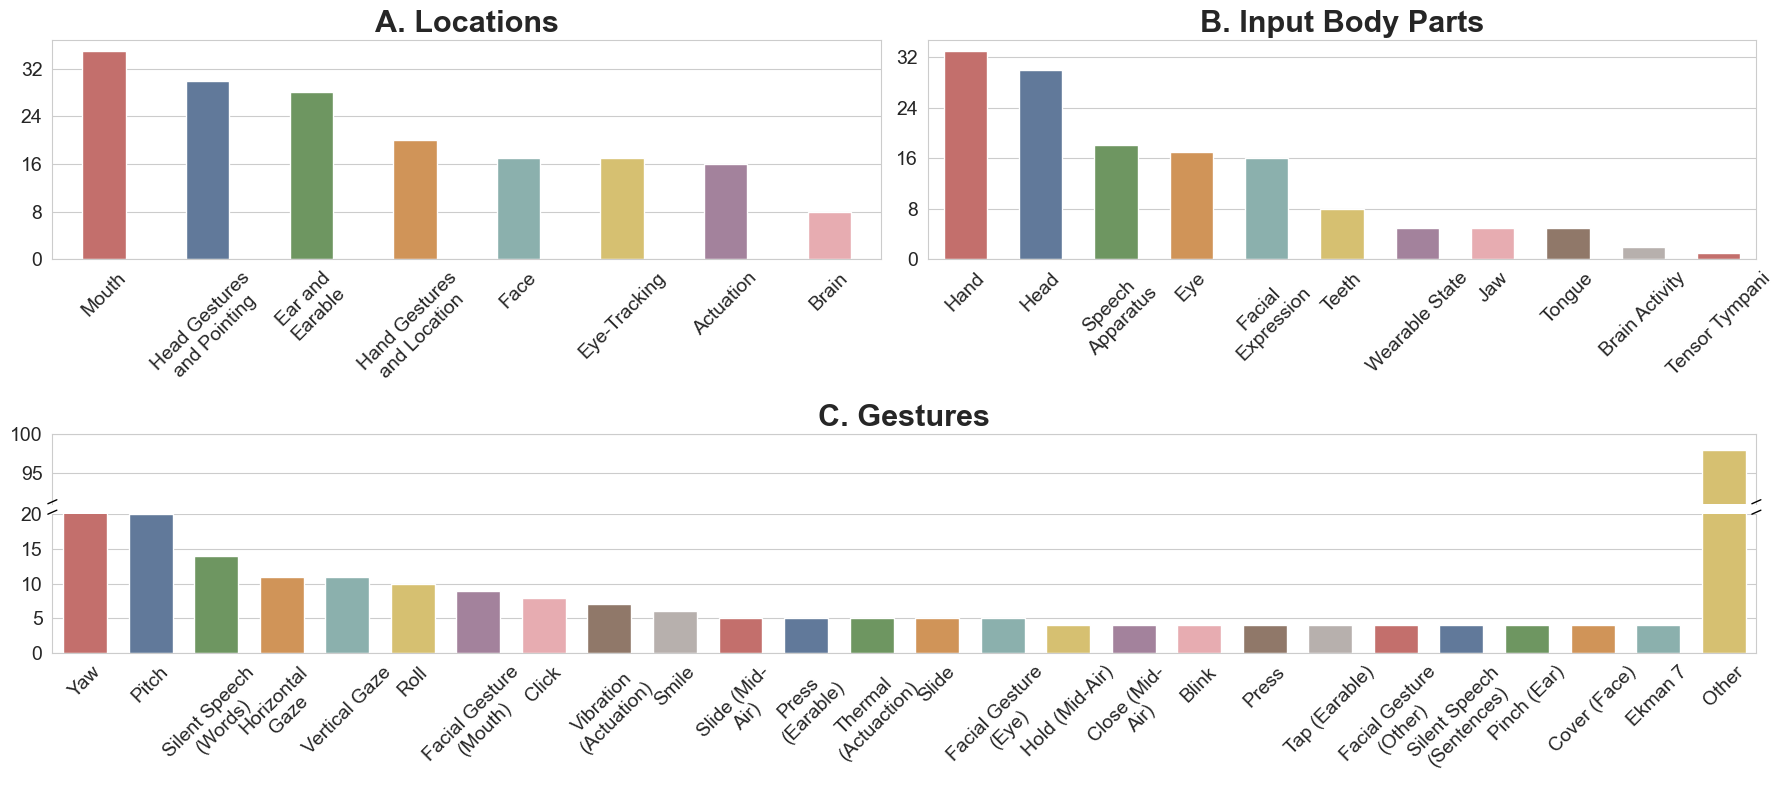

C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:222: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax13, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:231: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax14, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:240: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax15, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:249: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(x=l

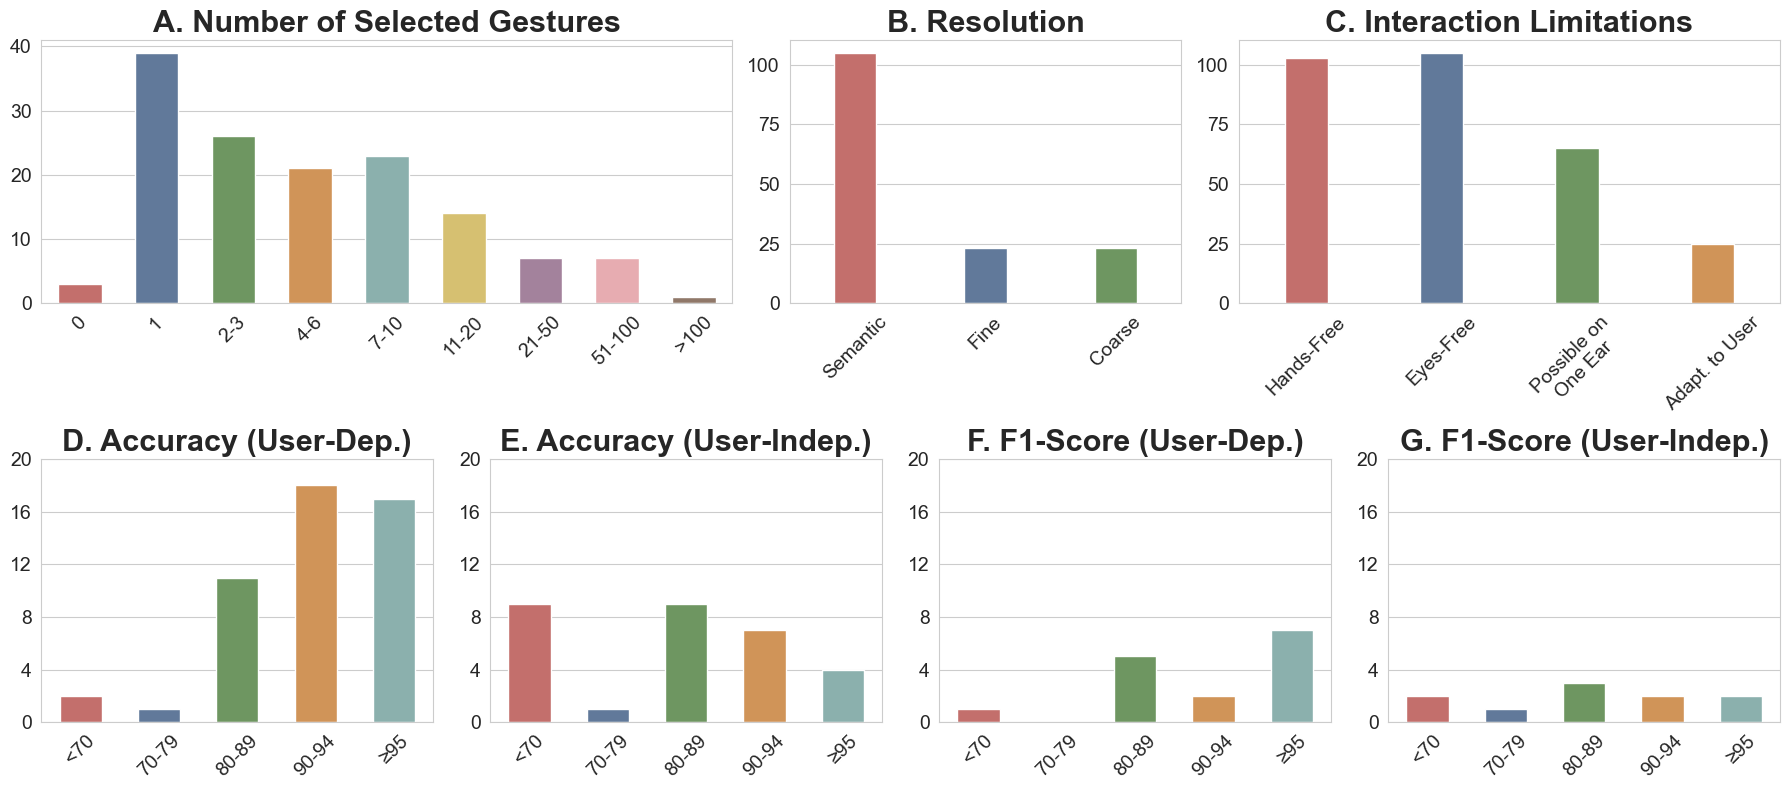

C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:297: UserWarning: 
The palette list has fewer values (10) than needed (16) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=labels, y=values, ax=ax20, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:306: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax21, hue=labels, palette=custom_colors, legend=False, width=bar_width)


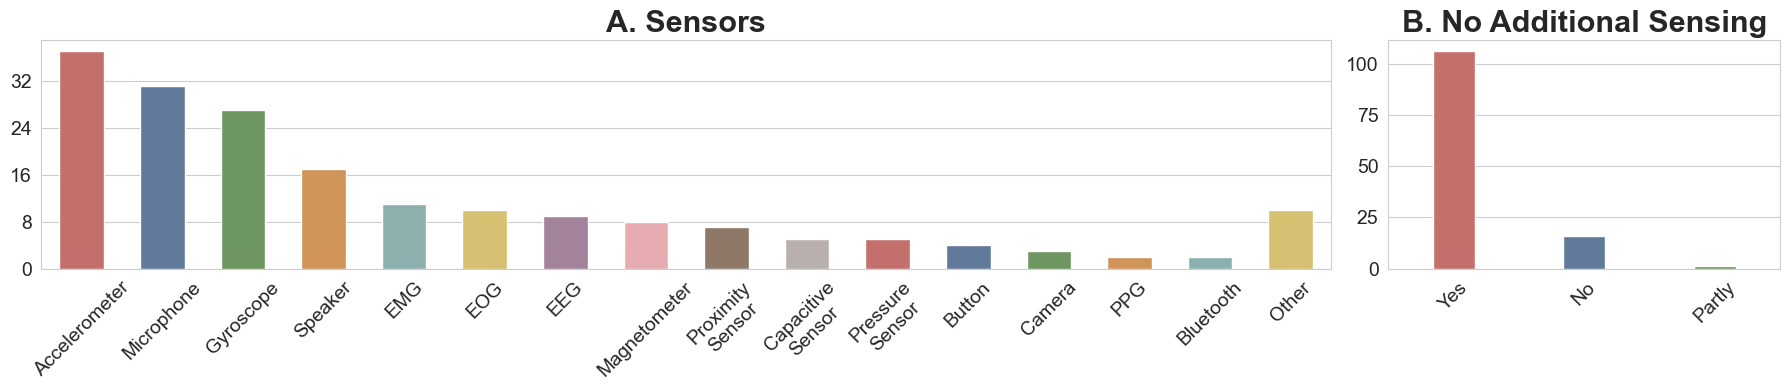

C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:325: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax4, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:334: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax_env, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:343: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax_dev, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:352: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an un

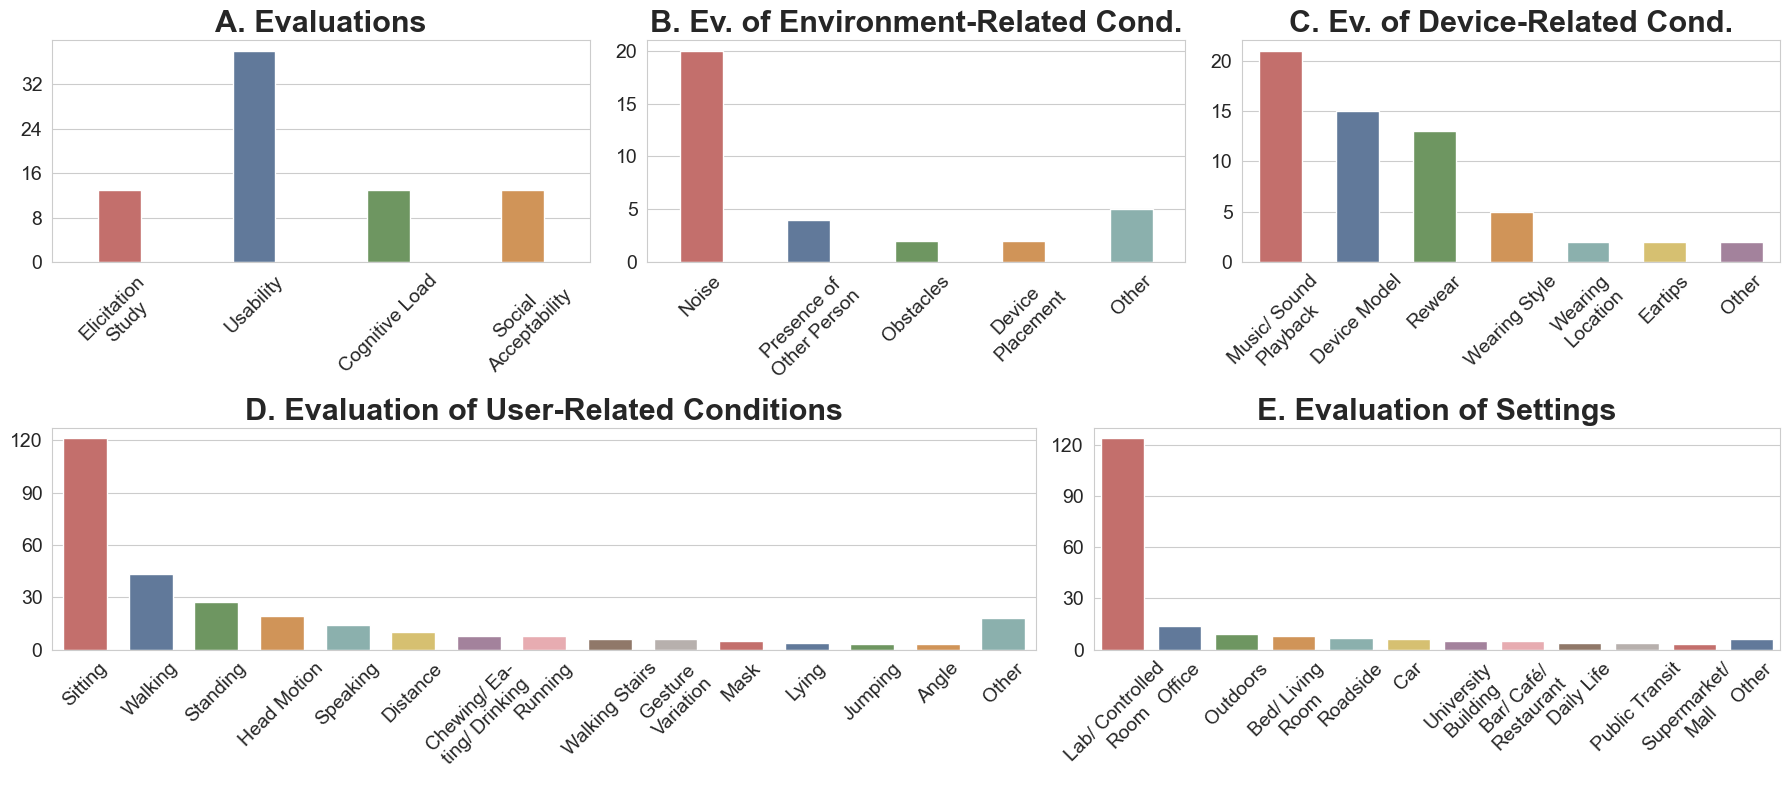

C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:378: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax8, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:387: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax9, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:396: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax10, hue=labels, palette=custom_colors, legend=False, width=bar_width)
C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:405: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.barplot(x=lab

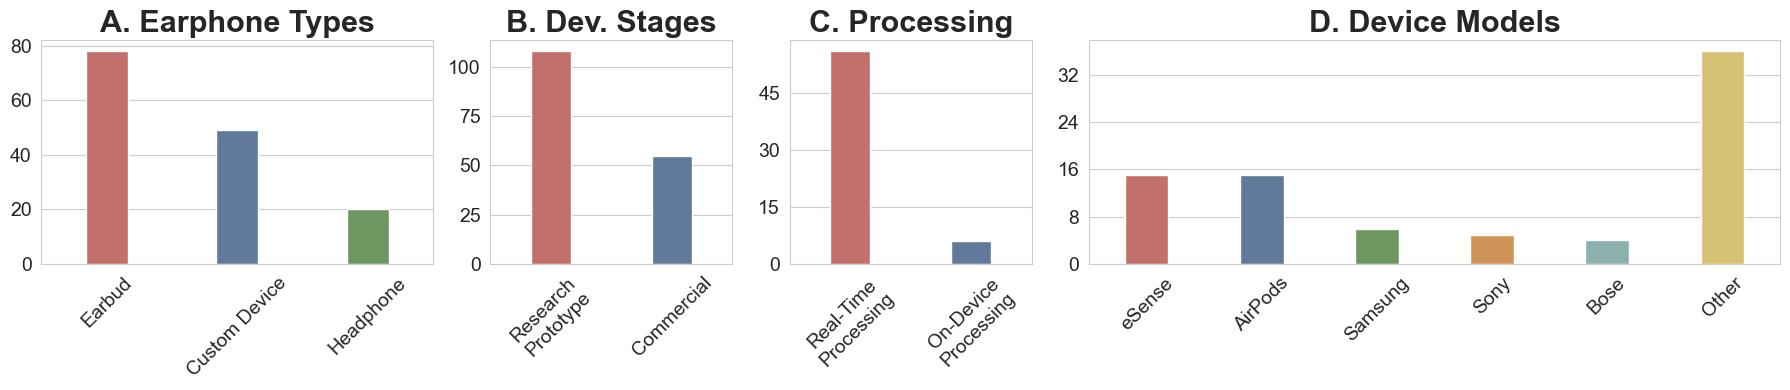

C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:422: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.barplot(x=labels, y=values, ax=ax11, hue=labels, palette=custom_colors, legend=False, width=bar_width)


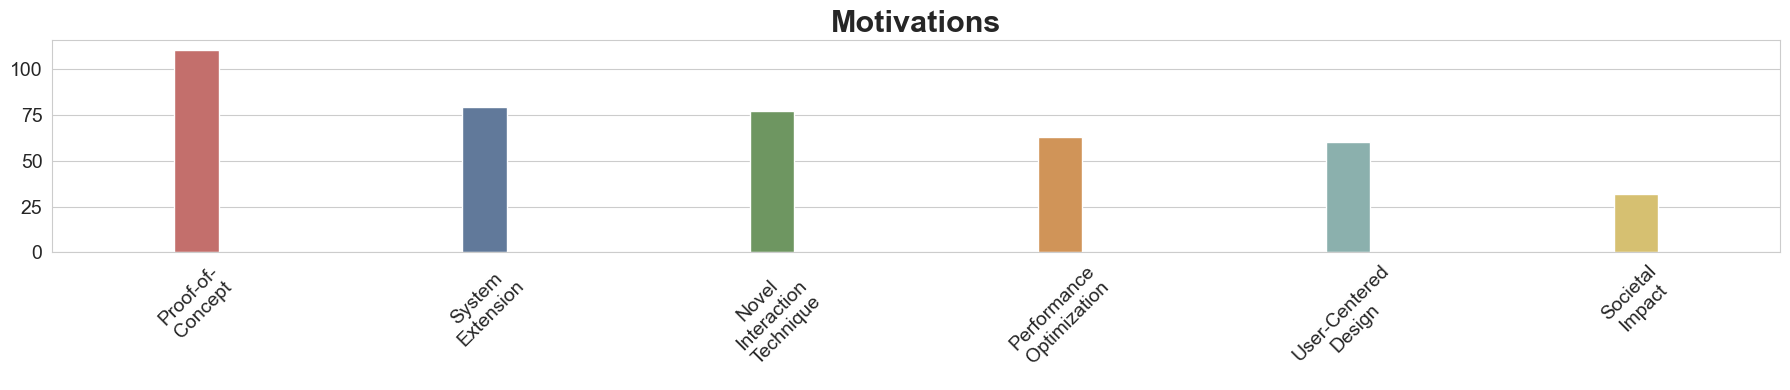

C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\2244215948.py:439: UserWarning: 
The palette list has fewer values (10) than needed (21) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=labels, y=values, ax=ax12, hue=labels, palette=custom_colors, legend=False, width=bar_width)


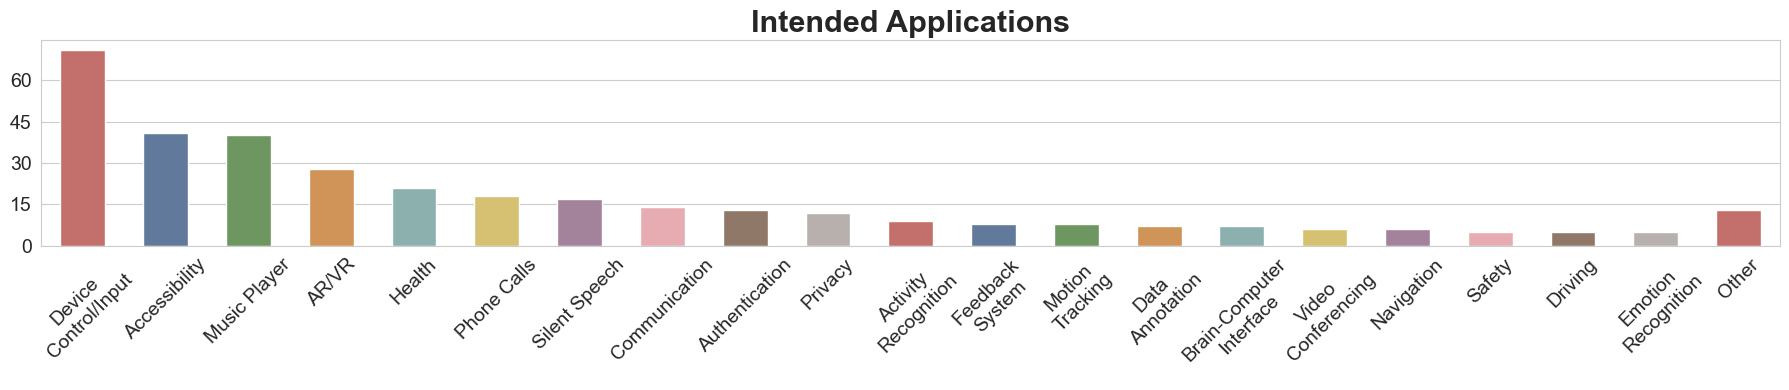

In [4]:
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Arial'] + plt.rcParams['font.serif']
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Define desired absolute bar width in inches
absolute_bar_width_inches = 0.3  # Adjust this to your preference

# Function to calculate appropriate seaborn width parameter
def calculate_bar_width(ax, num_bars, absolute_width_inches):
    bbox = ax.get_position()
    fig_width_inches = ax.figure.get_figwidth()
    subplot_width_inches = bbox.width * fig_width_inches
    width_param = (absolute_width_inches * num_bars) / subplot_width_inches * 1.2
    return min(width_param, 0.8)

# For a minimum count threshold (e.g., 5):
def aggregate_with_threshold(series, min_count=5):
    value_counts = series.dropna().str.split(',').explode().str.strip().value_counts()
    above_threshold = value_counts[value_counts >= min_count].to_dict()
    below_threshold_sum = value_counts[value_counts < min_count].sum()
    result = {**above_threshold}
    if below_threshold_sum > 0:
        result['Other'] = below_threshold_sum
    return result

# Gesture count buckets matching the EarXplore website (0, 1, 2-3, 4-6, 7-10, 11-20, 21-50, 51-100, >100)
# N/A is excluded per request
def create_gesture_bins(series):
    BUCKET_ORDER = ["0", "1", "2-3", "4-6", "7-10", "11-20", "21-50", "51-100", ">100"]

    def get_bucket(v):
        try:
            n = int(float(v))
        except (ValueError, TypeError):
            return None  # skip N/A
        if n == 0: return "0"
        if n == 1: return "1"
        if n <= 3: return "2-3"
        if n <= 6: return "4-6"
        if n <= 10: return "7-10"
        if n <= 20: return "11-20"
        if n <= 50: return "21-50"
        if n <= 100: return "51-100"
        return ">100"

    from collections import OrderedDict
    counts = OrderedDict((b, 0) for b in BUCKET_ORDER)
    for v in series.dropna():
        b = get_bucket(v)
        if b is not None:
            counts[b] += 1
    # Remove trailing zero buckets that were never populated
    return {k: v for k, v in counts.items() if v > 0}

def create_performance_bins(series):
    def parse_value(v):
        if pd.isna(v):
            return np.nan
        try:
            return float(str(v).split()[0])
        except (ValueError, IndexError):
            return np.nan

    numeric_series = series.apply(parse_value).dropna()
    bins = [0, 70, 80, 90, 95, 101]
    labels = ['<70', '70-79', '80-89', '90-94', '≥95']
    binned = pd.cut(numeric_series, bins=bins, labels=labels, include_lowest=True, right=False)
    value_counts = binned.value_counts()
    from collections import OrderedDict
    result = OrderedDict()
    for label in labels:
        result[label] = int(value_counts.get(label, 0))
    return result

def create_device_model_bins(series):
    """
    Aggregate Device Model column using keyword matching.
    Matches: eSense, AirPods, Samsung, Sony, Bose.
    OpenEarable is treated as Other (per request).
    N/A for empty/N/A entries. Other for no keyword match.
    Order: eSense, AirPods, Samsung, Sony, Bose, Other, N/A (only non-zero).
    """
    keywords = ["eSense", "AirPods", "Samsung", "Sony", "Bose"]
    order = keywords + ["Other", "N/A"]
    counts = {k: 0 for k in order}

    for cell in series.dropna():
        for part in str(cell).split(','):
            part = part.strip()
            if part == '' or part == 'N/A':
                counts['N/A'] += 1
                continue
            lower = part.lower()
            matched = False
            for kw in keywords:
                if kw.lower() in lower:
                    counts[kw] += 1
                    matched = True
                    break
            if not matched:
                counts['Other'] += 1

    return {k: v for k, v in counts.items() if v > 0}

# Extract data into dictionaries for labels and values
data_dict = [
    dict(df['Location'].dropna().str.split(',').explode().str.strip().value_counts()),                   # [0]
    dict(df['Input Body Part'].dropna().str.split(',').explode().str.strip().value_counts()),            # [1]
    aggregate_with_threshold(df['Gesture'], min_count=4),                                               # [2]
    create_gesture_bins(df['Interaction_PANEL_Number of Selected Gestures']),                           # [3]
    dict(df['Interaction_PANEL_Resolution'].dropna().str.split(',').explode().str.strip().value_counts()),  # [4]
    {                                                                                                    # [5]
        'Hands-Free': df['Interaction_PANEL_Hands-Free'].str.strip().str.contains('Yes', na=False).sum(),
        'Eyes-Free': df['Interaction_PANEL_Eyes-Free'].str.strip().str.contains('Yes', na=False).sum(),
        'Possible on One Ear': df['Interaction_PANEL_Possible on One Ear'].str.strip().eq('Yes').sum(),
        'Adapt. to User': df['Interaction_PANEL_Adaptation of the Interaction Detection Algorithm to User'].str.strip().str.contains('Yes', na=False).sum(),
    },
    create_performance_bins(df['Interaction_PANEL_Accuracy of Interaction Detection (User-Dependent)']),    # [6]
    create_performance_bins(df['Interaction_PANEL_Accuracy of Interaction Detection (User-Independent)']), # [7]
    create_performance_bins(df['Interaction_PANEL_F1-Score of Interaction Detection (User-Dependent)']),   # [8]
    create_performance_bins(df['Interaction_PANEL_F1-Score of Interaction Detection (User-Independent)']), # [9]
    aggregate_with_threshold(df['Sensing_PANEL_Sensors'], min_count=2),                                 # [10]
    dict(df['Sensing_PANEL_No Additional Sensing'].dropna().str.split(',').explode().str.strip().value_counts()),  # [11]
    {                                                                                                    # [12]
        'Elicitation Study': df['Study_PANEL_Elicitation Study'].str.strip().str.contains('Yes', na=False).sum(),
        'Usability': df['Study_PANEL_Usability Evaluations'].str.strip().str.contains('Yes', na=False).sum(),
        'Cognitive Load': df['Study_PANEL_Cognitive Load Evaluations'].str.strip().str.contains('Yes', na=False).sum(),
        'Social Acceptability': df['Study_PANEL_Social Acceptability of Interactions Evaluations'].str.strip().str.contains('Yes', na=False).sum(),
    },
    aggregate_with_threshold(df['Study_PANEL_Evaluation of Settings'], min_count=3),                    # [13]
    aggregate_with_threshold(df['Study_PANEL_Evaluation of Environment-Related Conditions'], min_count=2),  # [14]
    aggregate_with_threshold(df['Study_PANEL_Evaluation of User-Related Conditions'], min_count=3),     # [15]
    aggregate_with_threshold(df['Study_PANEL_Evaluation of Device-Related Conditions'], min_count=2),   # [16]
    dict(df['Device_PANEL_Earphone Type'].dropna().str.split(',').explode().str.strip().value_counts()), # [17]
    dict(df['Device_PANEL_Development Stage'].dropna().str.split(',').explode().str.strip().value_counts()),  # [18]
    {                                                                                                    # [19]
        'Real-Time Processing': df['Device_PANEL_Real-Time Processing'].str.strip().eq('Yes').sum(),
        'On-Device Processing': df['Device_PANEL_On-Device Processing'].str.strip().eq('Yes').sum()
    },
    create_device_model_bins(df['Device_PANEL_Device Model']),                                          # [20]
    dict(df['Motivations_PANEL_Motivations'].dropna().str.split(',').explode().str.strip().value_counts()),  # [21]
    aggregate_with_threshold(df['Applications_PANEL_Intended Applications'], min_count=5),              # [22]
]

custom_colors = ['#d1615d', '#5778a4', '#6a9f58', '#e49444', '#85b6b2', '#e7ca60', '#a87c9f', '#f1a2a9', '#967662', '#b8b0ac']

# ── Figure Q1 ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8))
gs = GridSpec(2, 12, width_ratios=[1]*12, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, :6])
labels, values = zip(*data_dict[0].items())
bar_width = calculate_bar_width(ax1, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax1, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax1.set_title("A. Locations", fontweight='bold')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax2 = fig.add_subplot(gs[0, 6:])
labels, values = zip(*data_dict[1].items())
bar_width = calculate_bar_width(ax2, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax2, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax2.set_title("B. Input Body Parts", fontweight='bold')
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax2.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

# Gestures – broken y-axis
gs_broken = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1, :], hspace=0.1, height_ratios=[1, 2])
ax3_top = fig.add_subplot(gs_broken[0])
ax3_bottom = fig.add_subplot(gs_broken[1])

labels, values = zip(*data_dict[2].items())
bar_width = calculate_bar_width(ax3_bottom, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax3_top, hue=labels, palette=custom_colors, legend=False, width=bar_width)
sns.barplot(x=labels, y=values, ax=ax3_bottom, hue=labels, palette=custom_colors, legend=False, width=bar_width)

ax3_top.set_ylim(bottom=91, top=100)
ax3_bottom.set_ylim(top=20)

ax3_top.set_title("C. Gestures", fontweight='bold')
ax3_top.spines['bottom'].set_visible(False)
ax3_top.set_xticks([])
ax3_top.set_xlabel('')
ax3_top.tick_params(axis='x', which='both', bottom=False)

ax3_bottom.spines['top'].set_visible(False)
ax3_bottom.set_xticks(range(len(labels)))
ax3_bottom.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax3_bottom.set_yticks([0, 5, 10, 15, 20])
ax3_bottom.set_yticklabels(['0', '5', '10', '15', '20'])

fig.tight_layout()
d = .005
top_pos = ax3_top.get_position()
bottom_pos = ax3_bottom.get_position()
for x in [top_pos.x0, top_pos.x1]:
    fig.add_artist(plt.Line2D([x - d/2, x + d/2], [top_pos.y0, top_pos.y0 + d],
                              transform=fig.transFigure, color='k', clip_on=False, linewidth=1))
for x in [bottom_pos.x0, bottom_pos.x1]:
    fig.add_artist(plt.Line2D([x - d/2, x + d/2], [bottom_pos.y1, bottom_pos.y1 + d],
                              transform=fig.transFigure, color='k', clip_on=False, linewidth=1))

plt.savefig("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/summary_q1.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure Q2 ──────────────────────────────────────────────────────────────────
PERF_YLIM = 20  # shared y-axis limit for all 4 performance charts

fig = plt.figure(figsize=(18, 8))
gs = GridSpec(2, 12, width_ratios=[1]*12, height_ratios=[1, 1])

ax13 = fig.add_subplot(gs[0, :5])
labels, values = zip(*data_dict[3].items())
bar_width = calculate_bar_width(ax13, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax13, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax13.set_title("A. Number of Selected Gestures", fontweight='bold')
ax13.set_xticks(range(len(labels)))
ax13.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax13.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax14 = fig.add_subplot(gs[0, 5:8])
labels, values = zip(*data_dict[4].items())
bar_width = calculate_bar_width(ax14, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax14, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax14.set_title("B. Resolution", fontweight='bold')
ax14.set_xticks(range(len(labels)))
ax14.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax14.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax15 = fig.add_subplot(gs[0, 8:])
labels, values = zip(*data_dict[5].items())
bar_width = calculate_bar_width(ax15, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax15, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax15.set_title("C. Interaction Limitations", fontweight='bold')
ax15.set_xticks(range(len(labels)))
ax15.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax15.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax16 = fig.add_subplot(gs[1, :3])
labels, values = zip(*data_dict[6].items())
bar_width = calculate_bar_width(ax16, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax16, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax16.set_title("D. Accuracy (User-Dep.)", fontweight='bold')
ax16.set_xticks(range(len(labels)))
ax16.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax16.set_ylim(0, PERF_YLIM)
ax16.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax17 = fig.add_subplot(gs[1, 3:6])
labels, values = zip(*data_dict[7].items())
bar_width = calculate_bar_width(ax17, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax17, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax17.set_title("E. Accuracy (User-Indep.)", fontweight='bold')
ax17.set_xticks(range(len(labels)))
ax17.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax17.set_ylim(0, PERF_YLIM)
ax17.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax18 = fig.add_subplot(gs[1, 6:9])
labels, values = zip(*data_dict[8].items())
bar_width = calculate_bar_width(ax18, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax18, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax18.set_title("F. F1-Score (User-Dep.)", fontweight='bold')
ax18.set_xticks(range(len(labels)))
ax18.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax18.set_ylim(0, PERF_YLIM)
ax18.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax19 = fig.add_subplot(gs[1, 9:])
labels, values = zip(*data_dict[9].items())
bar_width = calculate_bar_width(ax19, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax19, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax19.set_title("G. F1-Score (User-Indep.)", fontweight='bold')
ax19.set_xticks(range(len(labels)))
ax19.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax19.set_ylim(0, PERF_YLIM)
ax19.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

plt.tight_layout()
plt.savefig("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/summary_q2.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure Q3 ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 4))
gs = GridSpec(1, 12, width_ratios=[1]*12, height_ratios=[1])

ax20 = fig.add_subplot(gs[0, :9])
labels, values = zip(*data_dict[10].items())
bar_width = calculate_bar_width(ax20, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax20, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax20.set_title("A. Sensors", fontweight='bold')
ax20.set_xticks(range(len(labels)))
ax20.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax20.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax21 = fig.add_subplot(gs[0, 9:])
labels, values = zip(*data_dict[11].items())
bar_width = calculate_bar_width(ax21, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax21, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax21.set_title("B. No Additional Sensing", fontweight='bold')
ax21.set_xticks(range(len(labels)))
ax21.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax21.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

plt.tight_layout()
plt.savefig("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/summary_q3.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure Q4 ──────────────────────────────────────────────────────────────────
# Row 0: A. Evaluations | B. Ev. of Cond. (Environment-Related) | C. Ev. of Cond. (Device-Related)
# Row 1: D. Ev. of Cond. (User-Related) | E. Evaluation of Settings
fig = plt.figure(figsize=(18, 8))
gs = GridSpec(2, 12, width_ratios=[1]*12, height_ratios=[1, 1])

ax4 = fig.add_subplot(gs[0, :4])
labels, values = zip(*data_dict[12].items())
bar_width = calculate_bar_width(ax4, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax4, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax4.set_title("A. Evaluations", fontweight='bold')
ax4.set_xticks(range(len(labels)))
ax4.set_xticklabels([textwrap.fill(l.replace('/', '/ '), width=14) for l in labels], rotation=45, ha='center')
ax4.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax_env = fig.add_subplot(gs[0, 4:8])
labels, values = zip(*data_dict[14].items())
bar_width = calculate_bar_width(ax_env, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax_env, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax_env.set_title("B. Ev. of Environment-Related Cond.", fontweight='bold')
ax_env.set_xticks(range(len(labels)))
ax_env.set_xticklabels([textwrap.fill(l.replace('/', '/ '), width=14) for l in labels], rotation=45, ha='center')
ax_env.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax_dev = fig.add_subplot(gs[0, 8:])
labels, values = zip(*data_dict[16].items())
bar_width = calculate_bar_width(ax_dev, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax_dev, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax_dev.set_title("C. Ev. of Device-Related Cond.", fontweight='bold')
ax_dev.set_xticks(range(len(labels)))
ax_dev.set_xticklabels([textwrap.fill(l.replace('/', '/ '), width=14) for l in labels], rotation=45, ha='center')
ax_dev.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax5 = fig.add_subplot(gs[1, :7])
labels, values = zip(*data_dict[15].items())
bar_width = calculate_bar_width(ax5, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax5, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax5.set_title("D. Evaluation of User-Related Conditions", fontweight='bold')
ax5.set_xticks(range(len(labels)))
ax5.set_xticklabels(['Chewing/ Ea-\nting/ Drinking' if 'Chewing/Eating/Drinking' in l else textwrap.fill(l.replace('/', '/ '), width=16) for l in labels], rotation=45, ha='center')
ax5.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax7 = fig.add_subplot(gs[1, 7:])
labels, values = zip(*data_dict[13].items())
bar_width = calculate_bar_width(ax7, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax7, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax7.set_title("E. Evaluation of Settings", fontweight='bold')
ax7.set_xticks(range(len(labels)))
ax7.set_xticklabels([textwrap.fill(l.replace('/', '/ '), width=15) for l in labels], rotation=45, ha='center')
ax7.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

plt.tight_layout()
plt.savefig("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/summary_q4.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure Q5 ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 4))
gs = GridSpec(1, 12, width_ratios=[1]*12, height_ratios=[1])

ax8 = fig.add_subplot(gs[0, :3])
labels, values = zip(*data_dict[17].items())
bar_width = calculate_bar_width(ax8, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax8, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax8.set_title("A. Earphone Types", fontweight='bold')
ax8.set_xticks(range(len(labels)))
ax8.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax8.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax9 = fig.add_subplot(gs[0, 3:5])
labels, values = zip(*data_dict[18].items())
bar_width = calculate_bar_width(ax9, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax9, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax9.set_title("B. Dev. Stages", fontweight='bold')
ax9.set_xticks(range(len(labels)))
ax9.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax9.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax10 = fig.add_subplot(gs[0, 5:7])
labels, values = zip(*data_dict[19].items())
bar_width = calculate_bar_width(ax10, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax10, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax10.set_title("C. Processing", fontweight='bold')
ax10.set_xticks(range(len(labels)))
ax10.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax10.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

ax_dm = fig.add_subplot(gs[0, 7:])
labels, values = zip(*data_dict[20].items())
bar_width = calculate_bar_width(ax_dm, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax_dm, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax_dm.set_title("D. Device Models", fontweight='bold')
ax_dm.set_xticks(range(len(labels)))
ax_dm.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax_dm.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

plt.tight_layout()
plt.savefig("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/summary_q5.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure Q6 ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 4))
gs = GridSpec(1, 12, width_ratios=[1]*12, height_ratios=[1])

ax11 = fig.add_subplot(gs[0, :])
labels, values = zip(*data_dict[21].items())
bar_width = calculate_bar_width(ax11, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax11, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax11.set_title("Motivations", fontweight='bold')
ax11.set_xticks(range(len(labels)))
ax11.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax11.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

plt.tight_layout()
plt.savefig("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/summary_q6.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure Q7 ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 4))
gs = GridSpec(1, 12, width_ratios=[1]*12, height_ratios=[1])

ax12 = fig.add_subplot(gs[0, :])
labels, values = zip(*data_dict[22].items())
bar_width = calculate_bar_width(ax12, len(labels), absolute_bar_width_inches)
sns.barplot(x=labels, y=values, ax=ax12, hue=labels, palette=custom_colors, legend=False, width=bar_width)
ax12.set_title("Intended Applications", fontweight='bold')
ax12.set_xticks(range(len(labels)))
ax12.set_xticklabels([textwrap.fill(l, width=14) for l in labels], rotation=45, ha='center')
ax12.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

plt.tight_layout()
plt.savefig("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/summary_q7.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()


In [5]:
# --- Generate plain textual listings for each bar chart (Guiding Questions figures) ---

from pathlib import Path
from datetime import datetime

# Set to True to also write a markdown file with the listings
SAVE_MARKDOWN = True
MARKDOWN_PATH = Path("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/bar_chart_listings_guiding_questions.md")

# Order mode: 'original' keeps plotting order; 'descending' sorts by count desc; 'ascending' sorts by count asc
ORDER_MODE = 'original'

def ordered_items(d, mode='original'):
    items = list(d.items())
    if mode == 'descending':
        items.sort(key=lambda x: x[1], reverse=True)
    elif mode == 'ascending':
        items.sort(key=lambda x: x[1])
    return items

def format_line(letter, title, d, mode='original'):
    parts = [f"\"{k}\" = {v}" for k, v in ordered_items(d, mode)]
    prefix = f"{letter}. " if letter else ""
    return f"{prefix}{title}: " + ", ".join(parts)

# Mappings for the GUIDING QUESTION figures based on data_dict (defined above)
mapping_q1 = [
    (0, "A", "Locations"),
    (1, "B", "Input Body Parts"),
    (2, "C", "Gestures"),
]

mapping_q2 = [
    (3, "A", "Number of Selected Gestures"),
    (4, "B", "Resolution"),
    (5, "C", "Interaction Limitations"),
    (6, "D", "Accuracy (User-Dependent)"),
    (7, "E", "Accuracy (User-Independent)"),
    (8, "F", "F1-Score (User-Dependent)"),
    (9, "G", "F1-Score (User-Independent)"),
]

mapping_q3 = [
    (10, "A", "Sensors"),
    (11, "B", "No Additional Sensing"),
]

mapping_q4 = [
    (12, "A", "Evaluations"),
    (14, "B", "Evaluation of Environment-Related Conditions"),
    (16, "C", "Evaluation of Device-Related Conditions"),
    (15, "D", "Evaluation of User-Related Conditions"),
    (13, "E", "Evaluation of Settings"),
]

mapping_q5 = [
    (17, "A", "Earphone Types"),
    (18, "B", "Development Stages"),
    (19, "C", "Processing"),
    (20, "D", "Device Models"),
]

mapping_q6 = [
    (21, "", "Motivations"),
]

mapping_q7 = [
    (22, "", "Intended Applications"),
]

all_mappings = [
    ("summary_q1.pdf", mapping_q1),
    ("summary_q2.pdf", mapping_q2),
    ("summary_q3.pdf", mapping_q3),
    ("summary_q4.pdf", mapping_q4),
    ("summary_q5.pdf", mapping_q5),
    ("summary_q6.pdf", mapping_q6),
    ("summary_q7.pdf", mapping_q7),
]

lines = []
print("=== Bar Chart Listings (Guiding Questions) ===")
for fig_name, mapping in all_mappings:
    print(f"\n# Figure file: {fig_name}")
    lines.append(f"## {fig_name}")
    for idx, letter, title in mapping:
        if idx >= len(data_dict):
            continue
        line = format_line(letter, title, data_dict[idx], ORDER_MODE)
        print(line)
        lines.append(line)

if SAVE_MARKDOWN:
    MARKDOWN_PATH.parent.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")
    with MARKDOWN_PATH.open("w", encoding="utf-8") as f:
        f.write(f"# Bar Chart Listings (Guiding Questions)\nGenerated {timestamp}\n\n")
        for l in lines:
            f.write(l + "\n")
    print(f"\nSaved listings to: {MARKDOWN_PATH}")


=== Bar Chart Listings (Guiding Questions) ===

# Figure file: summary_q1.pdf
A. Locations: "Mouth" = 35, "Head Gestures and Pointing" = 30, "Ear and Earable" = 28, "Hand Gestures and Location" = 20, "Face" = 17, "Eye-Tracking" = 17, "Actuation" = 16, "Brain" = 8
B. Input Body Parts: "Hand" = 33, "Head" = 30, "Speech Apparatus" = 18, "Eye" = 17, "Facial Expression" = 16, "Teeth" = 8, "Wearable State" = 5, "Jaw" = 5, "Tongue" = 5, "Brain Activity" = 2, "Tensor Tympani" = 1
C. Gestures: "Yaw" = 25, "Pitch" = 20, "Silent Speech (Words)" = 14, "Horizontal Gaze" = 11, "Vertical Gaze" = 11, "Roll" = 10, "Facial Gesture (Mouth)" = 9, "Click" = 8, "Vibration (Actuation)" = 7, "Smile" = 6, "Slide (Mid-Air)" = 5, "Press (Earable)" = 5, "Thermal (Actuaction)" = 5, "Slide" = 5, "Facial Gesture (Eye)" = 5, "Hold (Mid-Air)" = 4, "Close (Mid-Air)" = 4, "Blink" = 4, "Press" = 4, "Tap (Earable)" = 4, "Facial Gesture (Other)" = 4, "Silent Speech (Sentences)" = 4, "Pinch (Ear)" = 4, "Cover (Face)" = 4, "

C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\1812576973.py:95: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")


#### Paper per Year Analysis

In [6]:
Counter(df['Year'].to_list())

Counter({2024: 19,
         2021: 16,
         2022: 13,
         2023: 12,
         2025: 11,
         2019: 10,
         2018: 9,
         2017: 7,
         2020: 7,
         2026: 6,
         2015: 5,
         2016: 5,
         2012: 4,
         2011: 3,
         2005: 2,
         2010: 2,
         2013: 2,
         2014: 2,
         1987: 1,
         2003: 1,
         2004: 1,
         2006: 1,
         2008: 1,
         2009: 1})

#### Timeline Locations

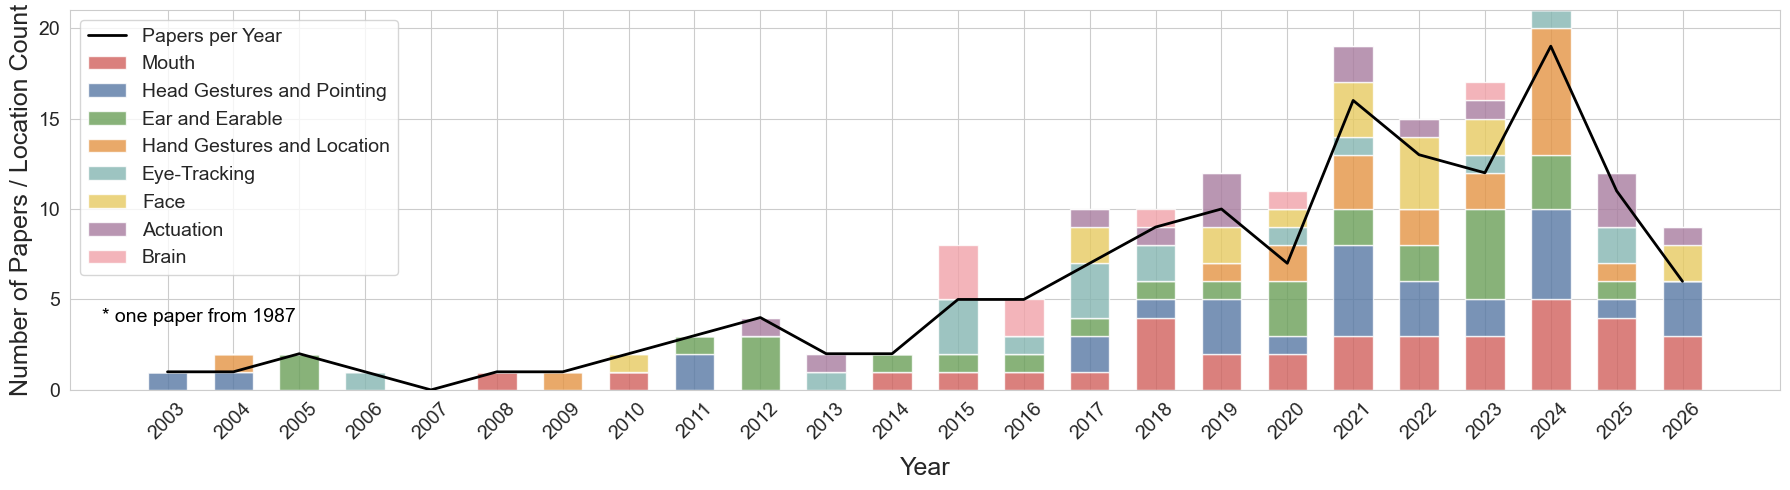

In [7]:
# get count of papers per year
year_counter = Counter(df['Year'].to_list())
papers_per_year = dict(year_counter.items())

# only take into account the sensors with at least 5 papers
target_locations = ['Actuation', 'Brain', 'Ear and Earable', 'Eye-Tracking', 'Face', 'Hand Gestures and Location', 'Head Gestures and Pointing', 'Mouth']

location_counts_by_year = defaultdict(lambda: defaultdict(int))

# Process each row
for index, row in df.iterrows():
    year = row['Year']
    locations_str = row['Location']
    
    # Skip if sensors field is NaN
    if pd.isna(locations_str):
        continue
    
    # Split by comma and clean up whitespace
    locations_in_row = [location.strip() for location in str(locations_str).split(',')]
    
    # Count each target sensor
    for location in locations_in_row:
        if location in target_locations:
            location_counts_by_year[year][location] += 1
        else:
            # Add to "Other" category
            location_counts_by_year[year]['Other'] += 1

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Arial'] + plt.rcParams['font.serif']
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Custom colors - add grey for "Other" category
custom_colors = ['#d1615d', '#5778a4', '#6a9f58', '#e49444', '#85b6b2', '#e7ca60', '#a87c9f', '#f1a2a9', '#967662', '#b8b0ac', '#cccccc']

# Get papers per year (excluding 1987)
papers_per_year_filtered = {year: count for year, count in papers_per_year.items() if year >= 2003}

# Convert sensor counts to regular dict and filter years
location_counts_regular = {year: dict(locations) for year, locations in location_counts_by_year.items() if year >= 2003}

# Create year range from 2003 to 2026
years = list(range(2003, 2027))

# Prepare data for plotting
papers_data = [papers_per_year_filtered.get(year, 0) for year in years]

# Prepare sensor data for stacked bars
target_locations_with_other = target_locations + ['Other']
location_data = {location: [] for location in target_locations_with_other}

for year in years:
    year_locations = location_counts_regular.get(year, {})
    for location in target_locations_with_other:
        location_data[location].append(year_locations.get(location, 0))

# Calculate total occurrences for each sensor and sort by count (descending)
location_totals = {location: sum(location_data[location]) for location in target_locations_with_other}

# Sort sensors but keep "Other" at the end
sorted_locations_temp = sorted(location_totals.items(), key=lambda x: x[1], reverse=True)
sorted_locations = []
other_location = None

# Separate "Other" from the rest
for location, total in sorted_locations_temp:
    if location == 'Other':
        other_location = (location, total)
    else:
        sorted_locations.append((location, total))

# Add "Other" at the end if it exists
if other_location:
    sorted_locations.append(other_location)

sorted_location_names = [location for location, total in sorted_locations if total > 0]

# Set figure size and style to match your existing plot
plt.figure(figsize=(18, 5))
sns.set_style("whitegrid")

# Create stacked bar chart with sorted sensors
bottom = np.zeros(len(years))

# Ensure we have enough colors for all sensors including "Other"
for i, location in enumerate(sorted_location_names):
    values = location_data[location]
    # Use the last color (grey) specifically for "Other"
    if location == 'Other':
        color = custom_colors[-1]  # Last color (grey)
    else:
        color = custom_colors[i % (len(custom_colors) - 1)]  # Exclude the last color for others
    
    plt.bar(years, values, bottom=bottom, label=location, color=color, alpha=0.8, width=0.6)
    bottom += values

# Add line plot for papers per year on the SAME axis
line = plt.plot(years, papers_data, color='black', linewidth=2, label='Papers per Year', zorder=10)

# Formatting to match your style
plt.xlabel('Year', labelpad=10)
plt.ylabel('Number of Papers / Location Count')

# Set x-axis ticks - show every other year to avoid crowding
plt.xticks(years, rotation=45)

# Set y-axis to show only integers (matching your style)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

# Legend matching your style
plt.legend(loc='upper left', bbox_to_anchor=(0, 1), fontsize=14)

# Add text annotation for 1987 paper
plt.text(2002, plt.ylim()[1] * 0.18, '* one paper from 1987', fontsize=14, 
         color='black', transform=plt.gca().transData)

plt.tight_layout()
plt.savefig("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/location_timeline_fig.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# --- Textual listings for Timeline Locations figure (overall + per year) ---

from pathlib import Path
from datetime import datetime

SAVE_MARKDOWN = True
INCLUDE_PER_YEAR = True
ORDER_MODE = 'descending'   # 'original' (current order in sorted_location_names), 'descending', 'ascending'
MARKDOWN_PATH = Path("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/location_timeline_listings.md")

def order_keys(keys, totals_dict, mode):
    if mode == 'original':
        return keys
    if mode == 'descending':
        return sorted(keys, key=lambda k: totals_dict[k], reverse=True)
    if mode == 'ascending':
        return sorted(keys, key=lambda k: totals_dict[k])
    return keys

# Reuse existing variables if already defined; otherwise (light) recompute essentials
try:
    _ = sorted_location_names
    _ = location_data
    _ = location_totals
    _ = years
except NameError:
    # Minimal recompute (assumes df is loaded)
    target_locations = ['Actuation', 'Brain', 'Ear and Earable', 'Eye-Tracking', 'Face',
                        'Hand Gestures and Location', 'Head Gestures and Pointing', 'Mouth']
    target_locations_with_other = target_locations + ['Other']
    year_counter = Counter(df['Year'].to_list())
    years = list(range(2003, 2025))
    location_counts_by_year = defaultdict(lambda: defaultdict(int))
    for _, row in df.iterrows():
        locs = row.get('Location')
        if pd.isna(locs):
            continue
        for location in str(locs).split(','):
            location = location.strip()
            if location in target_locations:
                location_counts_by_year[row['Year']][location] += 1
            else:
                location_counts_by_year[row['Year']]['Other'] += 1
    location_data = {loc: [] for loc in target_locations_with_other}
    for y in years:
        year_locs = location_counts_by_year.get(y, {})
        for loc in target_locations_with_other:
            location_data[loc].append(year_locs.get(loc, 0))
    location_totals = {loc: sum(location_data[loc]) for loc in target_locations_with_other}
    # Sort with "Other" last
    tmp = sorted(location_totals.items(), key=lambda x: x[1], reverse=True)
    ordered = []
    other_pair = None
    for loc, tot in tmp:
        if loc == 'Other':
            other_pair = (loc, tot)
        else:
            ordered.append((loc, tot))
    if other_pair:
        ordered.append(other_pair)
    sorted_locations = ordered
    sorted_location_names = [loc for loc, tot in sorted_locations if tot > 0]

# Decide final ordering for textual output
final_keys = order_keys(sorted_location_names, location_totals, ORDER_MODE)

lines = []
timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")
header = f"# Location Timeline Listings\nGenerated {timestamp}\n"
print(header.strip())
lines.append(header)

# Overall totals line
overall_parts = [f"\"{loc}\" = {location_totals[loc]}" for loc in final_keys]
overall_line = "Timeline Locations (Totals 2003–2026): " + ", ".join(overall_parts)
print(overall_line)
lines.append(overall_line + "\n")

if INCLUDE_PER_YEAR:
    print("\n# Per-Year Breakdown")
    lines.append("# Per-Year Breakdown\n")
    for yi, year in enumerate(years):
        # Skip years where all counts are zero
        if sum(location_data[loc][yi] for loc in final_keys) == 0:
            continue
        parts = [f"\"{loc}\" = {location_data[loc][yi]}" for loc in final_keys if location_data[loc][yi] > 0]
        year_line = f"{year}: " + ", ".join(parts) if parts else f"{year}: (no entries)"
        print(year_line)
        lines.append(year_line)

if SAVE_MARKDOWN:
    MARKDOWN_PATH.parent.mkdir(parents=True, exist_ok=True)
    with MARKDOWN_PATH.open("w", encoding="utf-8") as f:
        f.write("\n".join(lines) + "\n")
    print(f"\nSaved listings to: {MARKDOWN_PATH}")

# Location Timeline Listings
Generated 2026-06-08 14:48 UTC
Timeline Locations (Totals 2003–2026): "Mouth" = 35, "Head Gestures and Pointing" = 30, "Ear and Earable" = 28, "Hand Gestures and Location" = 20, "Eye-Tracking" = 17, "Face" = 17, "Actuation" = 15, "Brain" = 8

# Per-Year Breakdown
2003: "Head Gestures and Pointing" = 1
2004: "Head Gestures and Pointing" = 1, "Hand Gestures and Location" = 1
2005: "Ear and Earable" = 2
2006: "Eye-Tracking" = 1
2008: "Mouth" = 1
2009: "Hand Gestures and Location" = 1
2010: "Mouth" = 1, "Face" = 1
2011: "Head Gestures and Pointing" = 2, "Ear and Earable" = 1
2012: "Ear and Earable" = 3, "Actuation" = 1
2013: "Eye-Tracking" = 1, "Actuation" = 1
2014: "Mouth" = 1, "Ear and Earable" = 1
2015: "Mouth" = 1, "Ear and Earable" = 1, "Eye-Tracking" = 3, "Brain" = 3
2016: "Mouth" = 1, "Ear and Earable" = 1, "Eye-Tracking" = 1, "Brain" = 2
2017: "Mouth" = 1, "Head Gestures and Pointing" = 2, "Ear and Earable" = 1, "Eye-Tracking" = 3, "Face" = 2, "Actuatio

C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\22987020.py:68: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")


#### Keywords

In [9]:
keywords = df['Keywords'].dropna()
keywords

1               Gestural Interaction, Wearable Computing
2      Accelerometers, Control Systems, Digital Audio...
3      Bluetooth, Communication System Control, Ear, ...
4      Capacitive Touch Control, Headphones, MP3, Mus...
5      EOG, Gaze Interface, Headphone, Kalman Filter,...
                             ...                        
136    Acoustic Sensing, Contrastive Learning, Earabl...
137    Biometrics, Earables, Head Gestures, Out-Ear M...
138    Gaze Estimation, Head Pose, Inertial Measureme...
139    Earables, Human-Computer Interaction, In-Ear M...
140    Earable, Earbuds, Hearable, Human Activity Rec...
Name: Keywords, Length: 134, dtype: object

In [10]:
# Keywords
df['Keywords'].tolist()

# Step 1: Filter out NaN values and extract all keywords
all_keywords = []
for keywords in df['Keywords'].dropna():
    # Split by comma and strip whitespace
    terms = [term.strip() for term in keywords.split(',')]
    all_keywords.extend(terms)

# Step 2: Get unique keywords and count them
unique_keywords = set(all_keywords)
num_unique_keywords = len(unique_keywords)

# Count keywords per row (excluding NaN rows)
keyword_counts_per_row = []
for keywords in df['Keywords'].dropna():
    # Split by comma and strip whitespace
    terms = [term.strip() for term in keywords.split(',')]
    keyword_counts_per_row.append(len(terms))

# Calculate mean number of keywords per row
mean_keywords_per_row = np.mean(keyword_counts_per_row)

# Print results
print(f"Number of unique keywords: {num_unique_keywords}")
print(f"Mean number of keywords per row: {mean_keywords_per_row:.2f}")

Number of unique keywords: 448
Mean number of keywords per row: 4.87


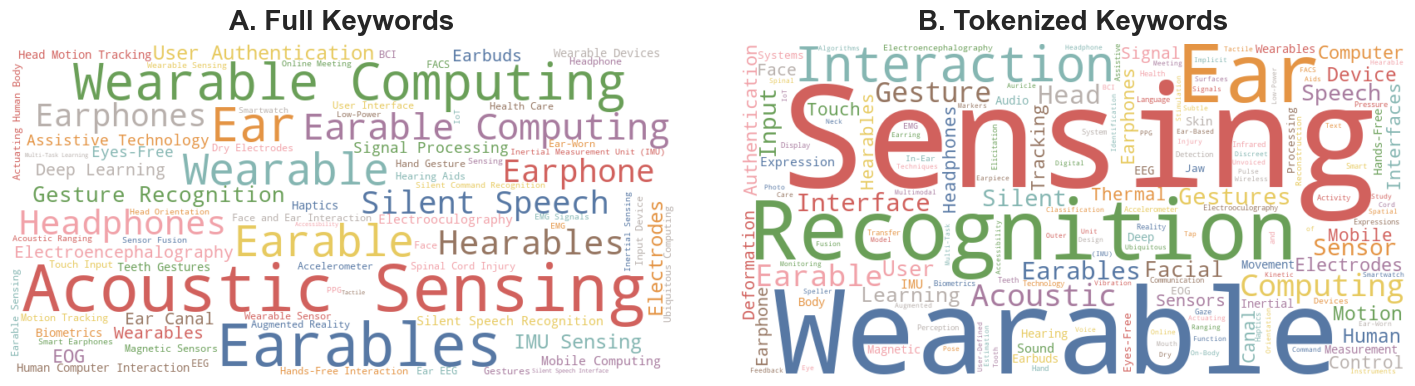

=== FULL KEYWORDS STATISTICS ===
Unique full keywords with ≥2 occurrences: 80
Most common full keywords:
  1. Acoustic Sensing: 19 (color: #d1615d)
  2. Earables: 16 (color: #5778a4)
  3. Wearable Computing: 11 (color: #6a9f58)
  4. Ear: 10 (color: #e49444)
  5. Wearable: 8 (color: #85b6b2)
  6. Earable: 8 (color: #e7ca60)
  7. Earable Computing: 8 (color: #a87c9f)
  8. Headphones: 7 (color: #f1a2a9)
  9. Hearables: 7 (color: #967662)
  10. Earphones: 6 (color: #b8b0ac)

=== INDIVIDUAL WORDS STATISTICS ===
Unique individual words with ≥2 occurrences: 166
Most common individual words:
  1. Sensing: 47 (color: #d1615d)
  2. Wearable: 31 (color: #5778a4)
  3. Recognition: 28 (color: #6a9f58)
  4. Ear: 27 (color: #e49444)
  5. Interaction: 24 (color: #85b6b2)
  6. Computing: 24 (color: #e7ca60)
  7. Acoustic: 24 (color: #a87c9f)
  8. Earable: 23 (color: #f1a2a9)
  9. Gesture: 20 (color: #967662)
  10. Head: 17 (color: #b8b0ac)


In [11]:
def create_keyword_wordclouds(df, min_count=2):
    """
    Create side-by-side wordclouds for full keywords and individual words.
    
    Parameters:
    df: DataFrame containing the 'Keywords' column
    min_count: Minimum occurrence count to include words/keywords
    """
    
    # Define your custom colors
    custom_colors = ['#d1615d', '#5778a4', '#6a9f58', '#e49444', '#85b6b2', '#e7ca60', '#a87c9f', '#f1a2a9', '#967662', '#b8b0ac']
    
    # Extract full keywords
    all_full_keywords = []
    for keywords in df['Keywords'].dropna():
        keyword_list = [keyword.strip() for keyword in keywords.split(',')]
        all_full_keywords.extend(keyword_list)
    
    # Extract individual words
    all_individual_words = []
    for keywords in df['Keywords'].dropna():
        keyword_list = [keyword.strip() for keyword in keywords.split(',')]
        for keyword in keyword_list:
            words = keyword.split()
            all_individual_words.extend(words)
    
    # Count occurrences
    full_keyword_counts = Counter(all_full_keywords)
    individual_word_counts = Counter(all_individual_words)
    
    # Apply min_count filter to create frequency dictionaries for WordCloud
    full_keyword_freq = {word: count for word, count in full_keyword_counts.items() if count >= min_count}
    individual_word_freq = {word: count for word, count in individual_word_counts.items() if count >= min_count}
    
    # Get sorted lists for color mapping (most frequent first, filtered by min_count)
    sorted_full_keywords = [word for word, count in full_keyword_counts.most_common() if count >= min_count]
    sorted_individual_words = [word for word, count in individual_word_counts.most_common() if count >= min_count]
    
    # Create color mappings based on rank
    full_keyword_colors = {word: custom_colors[i % len(custom_colors)] for i, word in enumerate(sorted_full_keywords)}
    individual_word_colors = {word: custom_colors[i % len(custom_colors)] for i, word in enumerate(sorted_individual_words)}
    
    # Color functions
    def color_func_full(word, **kwargs):
        return full_keyword_colors.get(word, custom_colors[0])
    
    def color_func_individual(word, **kwargs):
        return individual_word_colors.get(word, custom_colors[0])
    
    # Create figure with subplots
    plt.figure(figsize=(18, 5))
    
    # Full keywords wordcloud - now uses filtered frequencies
    plt.subplot(1, 2, 1)
    if full_keyword_freq:
        wordcloud1 = WordCloud(
            width=800, height=400, background_color='white',
            color_func=color_func_full,
            relative_scaling=0.5, random_state=42
        ).generate_from_frequencies(full_keyword_freq)
        plt.imshow(wordcloud1, interpolation='bilinear')
    plt.axis('off')
    plt.title('A. Full Keywords', fontsize=20, fontweight='bold', pad=10)

    # Individual words wordcloud - now uses filtered frequencies
    plt.subplot(1, 2, 2)
    if individual_word_freq:
        wordcloud2 = WordCloud(
            width=800, height=400, background_color='white',
            color_func=color_func_individual,
            relative_scaling=0.5, random_state=42
        ).generate_from_frequencies(individual_word_freq)
        plt.imshow(wordcloud2, interpolation='bilinear')
    plt.axis('off')
    plt.title('B. Tokenized Keywords', fontsize=20, fontweight='bold', pad=10)

    plt.subplots_adjust(wspace=0.1)
    plt.savefig("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/keywords_wordcloud_comparison.pdf", 
                format='pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print("=== FULL KEYWORDS STATISTICS ===")
    print(f"Unique full keywords with ≥{min_count} occurrences: {len(sorted_full_keywords)}")
    print("Most common full keywords:")
    for i, word in enumerate(sorted_full_keywords[:10]):
        count = full_keyword_counts[word]
        color = full_keyword_colors[word]
        print(f"  {i+1}. {word}: {count} (color: {color})")
    
    print(f"\n=== INDIVIDUAL WORDS STATISTICS ===")
    print(f"Unique individual words with ≥{min_count} occurrences: {len(sorted_individual_words)}")
    print("Most common individual words:")
    for i, word in enumerate(sorted_individual_words[:10]):
        count = individual_word_counts[word]
        color = individual_word_colors[word]
        print(f"  {i+1}. {word}: {count} (color: {color})")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Arial'] + plt.rcParams['font.serif']
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Call the function
create_keyword_wordclouds(df, min_count=2)

In [12]:
# --- Textual listings for Keyword Wordclouds (Full Keywords + Tokenized Words) ---

from pathlib import Path
from datetime import datetime

MIN_COUNT = 2              # Match the min_count used in create_keyword_wordclouds
ORDER_MODE = 'descending'  # 'original' | 'descending' | 'ascending'
LIMIT_FULL = None          # e.g. 50 or None
LIMIT_WORD = None          # e.g. 50 or None
SAVE_MARKDOWN = True
MARKDOWN_PATH = Path("C:/Users/jonas/Documents/Studium - PhD Informatik/Survey Paper Interaction/figs/keyword_wordcloud_listings.md")

def extract_keyword_frequencies(df, min_count):
    full_keywords = (
        df['Keywords']
        .dropna()
        .str.split(',')
        .explode()
        .str.strip()
    )
    full_counts = Counter(full_keywords)

    token_words = []
    for kw in df['Keywords'].dropna():
        for phrase in kw.split(','):
            for w in phrase.strip().split():
                token_words.append(w)
    token_counts = Counter(token_words)

    full_filtered = {k: v for k, v in full_counts.items() if v >= min_count}
    token_filtered = {k: v for k, v in token_counts.items() if v >= min_count}
    return full_filtered, token_filtered

def order_items(d, mode):
    items = list(d.items())
    if mode == 'descending':
        items.sort(key=lambda x: x[1], reverse=True)
    elif mode == 'ascending':
        items.sort(key=lambda x: x[1])
    return items  # 'original' keeps insertion order (Counter order Python 3.7+)

full_freq, token_freq = extract_keyword_frequencies(df, MIN_COUNT)
full_items = order_items(full_freq, ORDER_MODE)
token_items = order_items(token_freq, ORDER_MODE)

if LIMIT_FULL is not None:
    full_items = full_items[:LIMIT_FULL]
if LIMIT_WORD is not None:
    token_items = token_items[:LIMIT_WORD]

timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")

print(f"# Keyword Wordcloud Listings\nGenerated {timestamp}\n")
print(f"Parameters: MIN_COUNT={MIN_COUNT}, ORDER_MODE={ORDER_MODE}, LIMIT_FULL={LIMIT_FULL}, LIMIT_WORD={LIMIT_WORD}\n")

print(f"Full Keywords (≥{MIN_COUNT} occurrences):")
print(", ".join([f'\"{k}\" = {v}' for k, v in full_items]) or "(none)")
print()

print(f"Tokenized Words (≥{MIN_COUNT} occurrences):")
print(", ".join([f'\"{k}\" = {v}' for k, v in token_items]) or "(none)")

if SAVE_MARKDOWN:
    MARKDOWN_PATH.parent.mkdir(parents=True, exist_ok=True)
    with MARKDOWN_PATH.open("w", encoding="utf-8") as f:
        f.write(f"# Keyword Wordcloud Listings\nGenerated {timestamp}\n\n")
        f.write(f"Parameters: MIN_COUNT={MIN_COUNT}, ORDER_MODE={ORDER_MODE}, LIMIT_FULL={LIMIT_FULL}, LIMIT_WORD={LIMIT_WORD}\n\n")
        f.write(f"## Full Keywords (≥{MIN_COUNT})\n")
        f.write((", ".join([f'\"{k}\" = {v}' for k, v in full_items]) or "(none)") + "\n\n")
        f.write(f"## Tokenized Words (≥{MIN_COUNT})\n")
        f.write((", ".join([f'\"{k}\" = {v}' for k, v in token_items]) or "(none)") + "\n")
    print(f"\nSaved listings to: {MARKDOWN_PATH}")

# Keyword Wordcloud Listings
Generated 2026-06-08 14:48 UTC

Parameters: MIN_COUNT=2, ORDER_MODE=descending, LIMIT_FULL=None, LIMIT_WORD=None

Full Keywords (≥2 occurrences):
"Acoustic Sensing" = 19, "Earables" = 16, "Wearable Computing" = 11, "Ear" = 10, "Wearable" = 8, "Earable" = 8, "Earable Computing" = 8, "Headphones" = 7, "Hearables" = 7, "Earphones" = 6, "Earphone" = 6, "Silent Speech" = 6, "Gesture Recognition" = 6, "Electrodes" = 5, "IMU Sensing" = 5, "User Authentication" = 5, "EOG" = 4, "Electroencephalography" = 4, "Ear Canal" = 4, "Deep Learning" = 4, "Wearables" = 4, "Earbuds" = 4, "Signal Processing" = 3, "Assistive Technology" = 3, "Eyes-Free" = 3, "Silent Speech Recognition" = 3, "Mobile Computing" = 3, "Electrooculography" = 3, "Human Computer Interaction" = 3, "Wearable Devices" = 3, "Head Motion Tracking" = 3, "Haptics" = 3, "Teeth Gestures" = 3, "Biometrics" = 3, "Hearing Aids" = 2, "User Interface" = 2, "Headphone" = 2, "Spinal Cord Injury" = 2, "Hand Gesture" = 2

C:\Users\jonas\AppData\Local\Temp\ipykernel_25872\4044524080.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")


### Snapshot Text - Further Analyses

In [13]:
# ── Section 5.0 snapshot statistics ──────────────────────────────────────────
total = len(df)

since_2015 = (df['Year'] >= 2015).sum()
pct_since_2015 = since_2015 / total * 100

# "last five years" relative to the database cutoff (April 2026) → 2022-2026
last_5y_start = 2026 - 5 + 1   # = 2022
last_5y = (df['Year'] >= last_5y_start).sum()
pct_last_5y = last_5y / total * 100

print(f"Total studies:               {total}")
print(f"Published since 2015:        {since_2015}  ({pct_since_2015:.0f}%)")
print(f"Published {last_5y_start}–2026 (last 5y): {last_5y}  ({pct_last_5y:.0f}%)")


Total studies:               141
Published since 2015:        120  (85%)
Published 2022–2026 (last 5y): 61  (43%)


In [14]:

# ── Q1 General Information fact-check ─────────────────────────────────────────
import ast

# ── 1. Location counts (overall) ──────────────────────────────────────────────
from collections import Counter

all_locations = []
for loc_str in df['Location'].dropna():
    for loc in loc_str.split(','):
        all_locations.append(loc.strip())

loc_counts = Counter(all_locations)
print("=== Location counts (all studies) ===")
for loc, cnt in loc_counts.most_common():
    print(f"  {loc:<40} {cnt:>4}  ({cnt/len(df)*100:.0f}%)")

# ── 2. Hand Gestures and Location: share in 2024 ──────────────────────────────
hand_loc_label = "Hand Gestures and Location"
df_2024 = df[df['Year'] == 2024]
df_2025 = df[df['Year'] == 2025]
df_2026 = df[df['Year'] == 2026]

def has_location(row, label):
    return label in str(row['Location'])

hand_2024 = df_2024.apply(lambda r: has_location(r, hand_loc_label), axis=1).sum()
hand_2025 = df_2025.apply(lambda r: has_location(r, hand_loc_label), axis=1).sum()
hand_2026 = df_2026.apply(lambda r: has_location(r, hand_loc_label), axis=1).sum()
total_2024, total_2025, total_2026 = len(df_2024), len(df_2025), len(df_2026)

print(f"\n=== Hand Gestures and Location per recent year ===")
print(f"  2024: {hand_2024}/{total_2024}  ({hand_2024/total_2024*100:.0f}%)")
print(f"  2025: {hand_2025}/{total_2025}  ({hand_2025/total_2025*100:.0f}%)")
if total_2026:
    print(f"  2026: {hand_2026}/{total_2026}  ({hand_2026/total_2026*100:.0f}%)")

# ── 3. Input Body Parts ────────────────────────────────────────────────────────
all_parts = []
for p_str in df['Input Body Part'].dropna():
    for p in p_str.split(','):
        v = p.strip()
        if v and v != 'N/A':
            all_parts.append(v)

part_counts = Counter(all_parts)
print(f"\n=== Input Body Part counts ===")
for part, cnt in part_counts.most_common():
    print(f"  {part:<30} {cnt:>4}  ({cnt/len(df)*100:.0f}%)")

# ── 4. Distinct gesture types ─────────────────────────────────────────────────
all_gestures = []
for g_str in df['Gesture'].dropna():
    for g in g_str.split(','):
        v = g.strip()
        if v and v != 'N/A':
            all_gestures.append(v)

gesture_counts = Counter(all_gestures)
print(f"\n=== Gesture types: {len(gesture_counts)} distinct ===")
print("Top 15:")
for g, cnt in gesture_counts.most_common(15):
    print(f"  {g:<35} {cnt:>4}")


=== Location counts (all studies) ===
  Mouth                                      35  (25%)
  Head Gestures and Pointing                 30  (21%)
  Ear and Earable                            28  (20%)
  Hand Gestures and Location                 20  (14%)
  Eye-Tracking                               17  (12%)
  Face                                       17  (12%)
  Actuation                                  16  (11%)
  Brain                                       8  (6%)

=== Hand Gestures and Location per recent year ===
  2024: 7/19  (37%)
  2025: 1/11  (9%)
  2026: 0/6  (0%)

=== Input Body Part counts ===
  Hand                             33  (23%)
  Head                             30  (21%)
  Speech Apparatus                 18  (13%)
  Eye                              17  (12%)
  Facial Expression                16  (11%)
  Teeth                             8  (6%)
  Wearable State                    5  (4%)
  Jaw                               5  (4%)
  Tongue                 

In [15]:

# ── Q2 Interaction paragraph fact-check ───────────────────────────────────────
n = len(df)

def pct(x): return x / n * 100

# ── Gesture count: zero, >50 ──────────────────────────────────────────────────
def parse_n_gestures(v):
    try: return int(float(v))
    except: return None

gesture_nums = df['Interaction_PANEL_Number of Selected Gestures'].apply(parse_n_gestures)
zero_gestures = (gesture_nums == 0).sum()
over50_gestures = (gesture_nums > 50).sum()
print(f"Studies with 0 gestures:   {zero_gestures}")
print(f"Studies with >50 gestures: {over50_gestures}")

# ── Resolution ────────────────────────────────────────────────────────────────
res = df['Interaction_PANEL_Resolution'].dropna().str.split(',').explode().str.strip()
res_counts = res.value_counts()
print(f"\nResolution counts: {dict(res_counts)}")

# ── Hands-Free / Eyes-Free / both / One Ear / Adaptation ─────────────────────
hf = df['Interaction_PANEL_Hands-Free'].str.strip().str.contains('Yes', na=False)
ef = df['Interaction_PANEL_Eyes-Free'].str.strip().str.contains('Yes', na=False)
oe = df['Interaction_PANEL_Possible on One Ear'].str.strip().eq('Yes')
ad = df['Interaction_PANEL_Adaptation of the Interaction Detection Algorithm to User'].str.strip().str.contains('Yes', na=False)

hf_or_ef = (hf | ef).sum()
hf_and_ef = (hf & ef).sum()
oe_count = oe.sum()
ad_count = ad.sum()

print(f"\nHands-Free:            {hf.sum()}  ({pct(hf.sum()):.0f}%)")
print(f"Eyes-Free:             {ef.sum()}  ({pct(ef.sum()):.0f}%)")
print(f"Hands-Free OR Eyes-Free: {hf_or_ef}  ({pct(hf_or_ef):.0f}%)")
print(f"Hands-Free AND Eyes-Free: {hf_and_ef}  ({pct(hf_and_ef):.0f}%)")
print(f"Possible on One Ear:   {oe_count}  ({pct(oe_count):.0f}%)")
print(f"Adaptation to User:    {ad_count}  ({pct(ad_count):.0f}%)")

# ── Accuracy / F1 reporting rates (how many studies have any non-N/A value) ───
def has_value(series):
    return series.apply(lambda v: pd.notna(v) and str(v).strip() not in ('', 'N/A'))

acc_ud_mask  = has_value(df['Interaction_PANEL_Accuracy of Interaction Detection (User-Dependent)'])
acc_ui_mask  = has_value(df['Interaction_PANEL_Accuracy of Interaction Detection (User-Independent)'])
f1_ud_mask   = has_value(df['Interaction_PANEL_F1-Score of Interaction Detection (User-Dependent)'])
f1_ui_mask   = has_value(df['Interaction_PANEL_F1-Score of Interaction Detection (User-Independent)'])

acc_ud, acc_ui = acc_ud_mask.sum(), acc_ui_mask.sum()
f1_ud, f1_ui   = f1_ud_mask.sum(), f1_ui_mask.sum()

# Union: acc OR F1, per dependency type
any_ud = (acc_ud_mask | f1_ud_mask).sum()
any_ui = (acc_ui_mask | f1_ui_mask).sum()

print(f"\nReport accuracy (user-dep):     {acc_ud}  ({pct(acc_ud):.0f}%)")
print(f"Report accuracy (user-indep):   {acc_ui}  ({pct(acc_ui):.0f}%)")
print(f"Report F1 (user-dep):           {f1_ud}  ({pct(f1_ud):.0f}%)")
print(f"Report F1 (user-indep):         {f1_ui}  ({pct(f1_ui):.0f}%)")
print(f"\nReport accuracy OR F1 (user-dep):   {any_ud}  ({pct(any_ud):.0f}%)  ← XX% user-dependent")
print(f"Report accuracy OR F1 (user-indep): {any_ui}  ({pct(any_ui):.0f}%)  ← XX% user-independent")

# ── Adaptation trend: recent years ───────────────────────────────────────────
print(f"\nAdaptation to user — by year (where present):")
for yr in sorted(df['Year'].unique()):
    df_y = df[df['Year'] == yr]
    ad_y = df_y['Interaction_PANEL_Adaptation of the Interaction Detection Algorithm to User'].str.strip().str.contains('Yes', na=False).sum()
    if ad_y > 0:
        print(f"  {yr}: {ad_y}/{len(df_y)}  ({ad_y/len(df_y)*100:.0f}%)")


Studies with 0 gestures:   3
Studies with >50 gestures: 8

Resolution counts: {'Semantic': np.int64(105), 'Fine': np.int64(23), 'Coarse': np.int64(23)}

Hands-Free:            103  (73%)
Eyes-Free:             105  (74%)
Hands-Free OR Eyes-Free: 136  (96%)
Hands-Free AND Eyes-Free: 72  (51%)
Possible on One Ear:   65  (46%)
Adaptation to User:    25  (18%)

Report accuracy (user-dep):     49  (35%)
Report accuracy (user-indep):   30  (21%)
Report F1 (user-dep):           15  (11%)
Report F1 (user-indep):         10  (7%)

Report accuracy OR F1 (user-dep):   57  (40%)  ← XX% user-dependent
Report accuracy OR F1 (user-indep): 36  (26%)  ← XX% user-independent

Adaptation to user — by year (where present):
  2011: 1/3  (33%)
  2019: 1/10  (10%)
  2020: 2/7  (29%)
  2021: 3/16  (19%)
  2022: 3/13  (23%)
  2023: 3/12  (25%)
  2024: 5/19  (26%)
  2025: 6/11  (55%)
  2026: 1/6  (17%)


In [16]:

# ── Q3 Sensing paragraph fact-check ───────────────────────────────────────────
n = len(df)

# ── 1. Distinct sensing modalities ───────────────────────────────────────────
all_sensors = (
    df['Sensing_PANEL_Sensors']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .loc[lambda s: (s != '') & (s != 'N/A')]
)
sensor_counts = Counter(all_sensors)
print(f"Distinct sensing modalities: {len(sensor_counts)}")
print("\nAll sensor counts (descending):")
for s, c in sensor_counts.most_common():
    print(f"  {s:<40} {c:>4}  ({c/n*100:.0f}%)")

# ── 2. IMU / Microphone / Speaker counts and union ────────────────────────────
IMU_LABELS = {'Accelerometer', 'Gyroscope', 'Magnetometer'}
mic_labels_set = {k for k in sensor_counts if 'Microphone' in k}
spk_labels_set = {k for k in sensor_counts if 'Speaker' in k}

def has_any(row_val, label_set):
    if pd.isna(row_val):
        return False
    return bool(label_set & {x.strip() for x in str(row_val).split(',')})

has_imu = df['Sensing_PANEL_Sensors'].apply(lambda v: has_any(v, IMU_LABELS))
has_mic = df['Sensing_PANEL_Sensors'].apply(lambda v: has_any(v, mic_labels_set))
has_spk = df['Sensing_PANEL_Sensors'].apply(lambda v: has_any(v, spk_labels_set))

imu_or_mic = (has_imu | has_mic).sum()
mic_and_spk = (has_mic & has_spk).sum()

print(f"\nStudies with IMU (Accel/Gyro/Mag):  {has_imu.sum()}  ({has_imu.sum()/n*100:.0f}%)")
print(f"Studies with Microphone:            {has_mic.sum()}  ({has_mic.sum()/n*100:.0f}%)")
print(f"Studies with IMU OR Microphone:     {imu_or_mic}  ({imu_or_mic/n*100:.0f}%)  ← 'most studies'")
print(f"Studies with Speaker:               {has_spk.sum()}  ({has_spk.sum()/n*100:.0f}%)")
print(f"Mic AND Speaker:                    {mic_and_spk}  ({mic_and_spk/has_mic.sum()*100:.0f}% of mic studies)  ← 'often'")

# ── 3. Microphone trend over time ─────────────────────────────────────────────
print("\nMicrophone use by year (only years with ≥1 mic study):")
for yr in sorted(df['Year'].unique()):
    df_y = df[df['Year'] == yr]
    mic_y = df_y['Sensing_PANEL_Sensors'].apply(lambda v: has_any(v, mic_labels_set)).sum()
    total_y = len(df_y)
    if mic_y > 0:
        print(f"  {yr}: {mic_y}/{total_y}  ({mic_y/total_y*100:.0f}%)")


Distinct sensing modalities: 25

All sensor counts (descending):
  Accelerometer                              37  (26%)
  Microphone                                 31  (22%)
  Gyroscope                                  27  (19%)
  Speaker                                    17  (12%)
  EMG                                        11  (8%)
  EOG                                        10  (7%)
  EEG                                         9  (6%)
  Magnetometer                                8  (6%)
  Proximity Sensor                            7  (5%)
  Capacitive Sensor                           5  (4%)
  Pressure Sensor                             5  (4%)
  Button                                      4  (3%)
  Camera                                      3  (2%)
  Bluetooth                                   2  (1%)
  PPG                                         2  (1%)
  Laser                                       1  (1%)
  Projector                                   1  (1%)
  Resistive S

In [17]:

# ── Q4 Study paragraph fact-check ─────────────────────────────────────────────
n = len(df)
def pct(x): return x / n * 100

# ── Evaluation types: how many studies have ≥2, ≥3 types ─────────────────────
eval_cols = [
    'Study_PANEL_Elicitation Study',
    'Study_PANEL_Usability Evaluations',
    'Study_PANEL_Cognitive Load Evaluations',
    'Study_PANEL_Social Acceptability of Interactions Evaluations',
]
def has_eval(series):
    return series.apply(lambda v: pd.notna(v) and str(v).strip() not in ('', 'N/A') and 'Yes' in str(v))

eval_matrix = pd.concat([has_eval(df[c]).rename(c) for c in eval_cols], axis=1)
eval_counts_per_study = eval_matrix.sum(axis=1)

at_least_1 = (eval_counts_per_study >= 1).sum()
at_least_2 = (eval_counts_per_study >= 2).sum()
at_least_3 = (eval_counts_per_study >= 3).sum()
print(f"Studies with ≥1 evaluation type:  {at_least_1}  ({pct(at_least_1):.0f}%)")
print(f"Studies with ≥2 evaluation types: {at_least_2}  ({pct(at_least_2):.0f}%)")
print(f"Studies with ≥3 evaluation types: {at_least_3}  ({pct(at_least_3):.0f}%)")

# ── Evaluation Settings: outside Lab/Controlled Room ─────────────────────────
LAB_SETTINGS = {'Lab/Controlled Room'}

def is_outside_lab(v):
    if pd.isna(v) or str(v).strip() in ('', 'N/A'):
        return False
    settings = {s.strip() for s in str(v).split(',')}
    return bool(settings - LAB_SETTINGS)

def has_multiple_settings(v):
    if pd.isna(v) or str(v).strip() in ('', 'N/A'):
        return False
    settings = [s.strip() for s in str(v).split(',') if s.strip() not in ('', 'N/A')]
    return len(settings) >= 2

outside_lab = df['Study_PANEL_Evaluation of Settings'].apply(is_outside_lab).sum()
print(f"\nStudies with ≥1 non-lab setting: {outside_lab}  ({pct(outside_lab):.0f}%)")

# ── Environment-Related / Device-Related Conditions ───────────────────────────
def has_condition(v):
    return pd.notna(v) and str(v).strip() not in ('', 'N/A')

env_mask = df['Study_PANEL_Evaluation of Environment-Related Conditions'].apply(has_condition)
dev_mask = df['Study_PANEL_Evaluation of Device-Related Conditions'].apply(has_condition)
env_count = env_mask.sum()
dev_count = dev_mask.sum()
print(f"\nStudies with Environment-Related Conditions: {env_count}  ({pct(env_count):.0f}%)")
print(f"Studies with Device-Related Conditions:      {dev_count}  ({pct(dev_count):.0f}%)  ← XX%")

# ── User-Related Conditions: beyond basic Sitting ────────────────────────────
NON_SITTING = lambda v: (
    pd.notna(v) and str(v).strip() not in ('', 'N/A') and
    bool({s.strip() for s in str(v).split(',')} - {'Sitting', 'N/A', ''})
)
user_beyond_mask = df['Study_PANEL_Evaluation of User-Related Conditions'].apply(NON_SITTING)
user_beyond_sitting = user_beyond_mask.sum()
print(f"\nStudies with User-Related Conditions beyond Sitting: {user_beyond_sitting}  ({pct(user_beyond_sitting):.0f}%)")

# ── 2025: multiple real-world settings ───────────────────────────────────────
df_2025 = df[df['Year'] == 2025]
df_2024 = df[df['Year'] == 2024]
n2025, n2024 = len(df_2025), len(df_2024)

multi_settings_2025 = df_2025['Study_PANEL_Evaluation of Settings'].apply(has_multiple_settings).sum()
outside_lab_2025    = df_2025['Study_PANEL_Evaluation of Settings'].apply(is_outside_lab).sum()
print(f"\n2025 studies with multiple settings:  {multi_settings_2025}/{n2025}  ({multi_settings_2025/n2025*100:.0f}%)")
print(f"2025 studies with ≥1 non-lab setting: {outside_lab_2025}/{n2025}  ({outside_lab_2025/n2025*100:.0f}%)")
s2025 = df_2025['Study_PANEL_Evaluation of Settings'].dropna().str.split(',').explode().str.strip().loc[lambda s: s != ''].value_counts()
print("  2025 settings breakdown:", dict(s2025))

# ── since 2024 (2024+2025+2026): ≥1 condition BEYOND standard ────────────────
df_since2024 = df[df['Year'] >= 2024]
n_since2024 = len(df_since2024)

env_s24    = df_since2024['Study_PANEL_Evaluation of Environment-Related Conditions'].apply(has_condition)
dev_s24    = df_since2024['Study_PANEL_Evaluation of Device-Related Conditions'].apply(has_condition)
user_s24   = df_since2024['Study_PANEL_Evaluation of User-Related Conditions'].apply(NON_SITTING)

any_cond_since2024 = (env_s24 | dev_s24 | user_s24).sum()
print(f"\nSince-2024 studies with ≥1 condition beyond standard: {any_cond_since2024}/{n_since2024}  ({any_cond_since2024/n_since2024*100:.0f}%)  ← 'more than two-thirds'")
print(f"  (env: {env_s24.sum()}, device: {dev_s24.sum()}, user-beyond-sitting: {user_s24.sum()})")
print(f"  Per year: 2024={len(df[df['Year']==2024])}, 2025={len(df[df['Year']==2025])}, 2026={len(df[df['Year']==2026])}")


Studies with ≥1 evaluation type:  49  (35%)
Studies with ≥2 evaluation types: 18  (13%)
Studies with ≥3 evaluation types: 9  (6%)

Studies with ≥1 non-lab setting: 40  (28%)

Studies with Environment-Related Conditions: 28  (20%)
Studies with Device-Related Conditions:      46  (33%)  ← XX%

Studies with User-Related Conditions beyond Sitting: 65  (46%)

2025 studies with multiple settings:  5/11  (45%)
2025 studies with ≥1 non-lab setting: 5/11  (45%)
  2025 settings breakdown: {'Lab/Controlled Room': np.int64(11), 'Bed/Living Room': np.int64(2), 'Daily Life': np.int64(2), 'Office': np.int64(2), 'Car': np.int64(1), 'Wheelchair': np.int64(1), 'Bar/Café/Restaurant': np.int64(1), 'Cafeteria': np.int64(1), 'Roadside': np.int64(1)}

Since-2024 studies with ≥1 condition beyond standard: 25/36  (69%)  ← 'more than two-thirds'
  (env: 14, device: 17, user-beyond-sitting: 21)
  Per year: 2024=19, 2025=11, 2026=6


In [18]:

# ── Q5 Device paragraph fact-check ────────────────────────────────────────────
n = len(df)
def pct(x): return x / n * 100

# ── Earphone Types ────────────────────────────────────────────────────────────
earphone_counts = (
    df['Device_PANEL_Earphone Type']
    .dropna()
    .str.split(',').explode().str.strip()
    .loc[lambda s: s != '']
    .value_counts()
)
print("=== Earphone Types ===")
for t, c in earphone_counts.items():
    print(f"  {t:<30} {c:>4}  ({c/n*100:.0f}%)")

# ── Development Stage ─────────────────────────────────────────────────────────
dev_stage_counts = (
    df['Device_PANEL_Development Stage']
    .dropna()
    .str.split(',').explode().str.strip()
    .loc[lambda s: s != '']
    .value_counts()
)
print("\n=== Development Stage ===")
for t, c in dev_stage_counts.items():
    print(f"  {t:<30} {c:>4}  ({c/n*100:.0f}%)")

# ── Device Model keyword counts ──────────────────────────────────────────────
keywords_dm = ['eSense', 'AirPods', 'Samsung', 'Sony', 'Bose']
print("\n=== Device Model keyword counts ===")
for kw in keywords_dm:
    count = df['Device_PANEL_Device Model'].apply(
        lambda v: pd.notna(v) and kw.lower() in str(v).lower()
    ).sum()
    print(f"  {kw:<12} {count:>4}")

# ── Real-Time / On-Device Processing ─────────────────────────────────────────
rt = df['Device_PANEL_Real-Time Processing'].str.strip().eq('Yes').sum()
od = df['Device_PANEL_On-Device Processing'].str.strip().eq('Yes').sum()
print(f"\nReal-Time Processing: {rt}  ({pct(rt):.0f}%)")
print(f"On-Device Processing: {od}  ({pct(od):.0f}%)")


=== Earphone Types ===
  Earbud                           78  (55%)
  Custom Device                    49  (35%)
  Headphone                        20  (14%)

=== Development Stage ===
  Research Prototype              108  (77%)
  Commercial                       55  (39%)

=== Device Model keyword counts ===
  eSense         15
  AirPods        12
  Samsung         6
  Sony            4
  Bose            4

Real-Time Processing: 56  (40%)
On-Device Processing: 6  (4%)


In [19]:

# ── Q6 Motivations paragraph fact-check ───────────────────────────────────────
n = len(df)

motiv_counts = (
    df['Motivations_PANEL_Motivations']
    .dropna()
    .str.split(',').explode().str.strip()
    .loc[lambda s: s != '']
    .value_counts()
)
print("=== Motivations (all, descending) ===")
for m, c in motiv_counts.items():
    print(f"  {m:<45} {c:>4}  ({c/n*100:.0f}%)")


=== Motivations (all, descending) ===
  Proof-of-Concept                               110  (78%)
  System Extension                                79  (56%)
  Novel Interaction Technique                     77  (55%)
  Performance Optimization                        63  (45%)
  User-Centered Design                            60  (43%)
  Societal Impact                                 32  (23%)


In [20]:

# ── Q7 Intended Applications paragraph fact-check ─────────────────────────────
n = len(df)

app_counts = (
    df['Applications_PANEL_Intended Applications']
    .dropna()
    .str.split(',').explode().str.strip()
    .loc[lambda s: s != '']
    .value_counts()
)
print("=== Intended Applications (all, descending) ===")
for a, c in app_counts.items():
    print(f"  {a:<40} {c:>4}  ({c/n*100:.0f}%)")


=== Intended Applications (all, descending) ===
  Device Control/Input                       71  (50%)
  Accessibility                              41  (29%)
  Music Player                               40  (28%)
  AR/VR                                      28  (20%)
  Health                                     21  (15%)
  Phone Calls                                18  (13%)
  Silent Speech                              17  (12%)
  Communication                              14  (10%)
  Authentication                             13  (9%)
  Privacy                                    12  (9%)
  Activity Recognition                        9  (6%)
  Feedback System                             8  (6%)
  Motion Tracking                             8  (6%)
  Data Annotation                             7  (5%)
  Brain-Computer Interface                    7  (5%)
  Video Conferencing                          6  (4%)
  Navigation                                  6  (4%)
  Safety                  

In [21]:

# ── Q8 Keywords paragraph fact-check ──────────────────────────────────────────
import re

n = len(df)

kw_series = (
    df['Keywords']
    .dropna()
    .str.split(',').explode().str.strip()
    .loc[lambda s: s != '']
)

distinct_kws = kw_series.nunique()
n_with_keywords = df['Keywords'].notna().sum()

# Studies where at least one keyword contains "ear" at a word-start boundary
has_ear = df['Keywords'].dropna().str.lower().str.contains(r'\bear', regex=True)
ear_count = has_ear.sum()

# Studies where at least one keyword references an earable device type
DEVICE_TERMS = [
    'earbud', 'earbuds', 'wireless earbuds',
    'earphone', 'earphones', 'smart earphone', 'smart earphones',
    'headphone', 'headphones',
    'in-ear',
    'hearable', 'hearables',
    'airpod', 'airpods',
    'earpiece', 'wearable earpiece',
    'earhook',
    'ear clip',
    'hearing aid', 'hearing aids', 'hearing device', 'hearing instruments',
]
device_pattern = '|'.join(re.escape(t) for t in DEVICE_TERMS)
has_device = df['Keywords'].dropna().str.lower().str.contains(device_pattern, regex=True)
device_count = has_device.sum()

print(f"Studies with Keywords entry : {n_with_keywords}/{n} ({n_with_keywords/n*100:.0f}%)")
print(f"Distinct keyword terms      : {distinct_kws}  (paragraph says 448)")
print(f"Studies with 'ear' keyword  : {ear_count}/{n_with_keywords} = {ear_count/n_with_keywords*100:.0f}%  (paragraph says 60%)")
print(f"Studies with device keyword : {device_count}/{n_with_keywords} = {device_count/n_with_keywords*100:.0f}%  (paragraph says 31%)")
print()
print("--- Device keyword breakdown ---")
for term in DEVICE_TERMS:
    cnt = df['Keywords'].dropna().str.lower().str.contains(re.escape(term)).sum()
    if cnt > 0:
        print(f"  {term:<30} {cnt}")


Studies with Keywords entry : 134/141 (95%)
Distinct keyword terms      : 448  (paragraph says 448)
Studies with 'ear' keyword  : 81/134 = 60%  (paragraph says 60%)
Studies with device keyword : 49/134 = 37%  (paragraph says 31%)

--- Device keyword breakdown ---
  earbud                         6
  earbuds                        5
  wireless earbuds               1
  earphone                       15
  earphones                      8
  smart earphone                 2
  smart earphones                2
  headphone                      9
  headphones                     7
  in-ear                         4
  hearable                       9
  hearables                      7
  earpiece                       2
  wearable earpiece              1
  earhook                        1
  ear clip                       1
  hearing aid                    3
  hearing aids                   2
  hearing device                 1
  hearing instruments            1
